# 03 — Does daily sentiment correlate with market movement?

Two different questions, kept strictly apart:

1. **Same-day** — sentiment(t) vs return(t−1 → t). Many headlines are recaps
   written *after* the move ("Stocks Plunge As…"), so this measures
   contemporaneous association contaminated by reverse causality. It validates
   the scorer; it is **not** predictive skill.
2. **Next-day** — sentiment(t) vs return(t → t+1). Day-t headlines exist before
   the close that defines this move. This is the actual research question.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

from src.data import load_headlines
from src.sentiment import score_headlines
from src.features import build_model_frame
from src.analysis import corr_table, hac_regression, direction_table, subgroup_correlations

scored = score_headlines(load_headlines())
df = build_model_frame(scored)
corr = corr_table(df)
corr.round(4)

,relationship,n,pearson_r,pearson_p,spearman_r,spearman_p
0,same-day,3506,0.1793,0.0000,0.1901,0.0000
1,next-day,3210,0.0314,0.0756,0.0436,0.0135


Same-day correlation is far stronger than next-day — exactly the signature of
recap headlines describing the move that already happened. The honest headline
number for prediction is the next-day row.

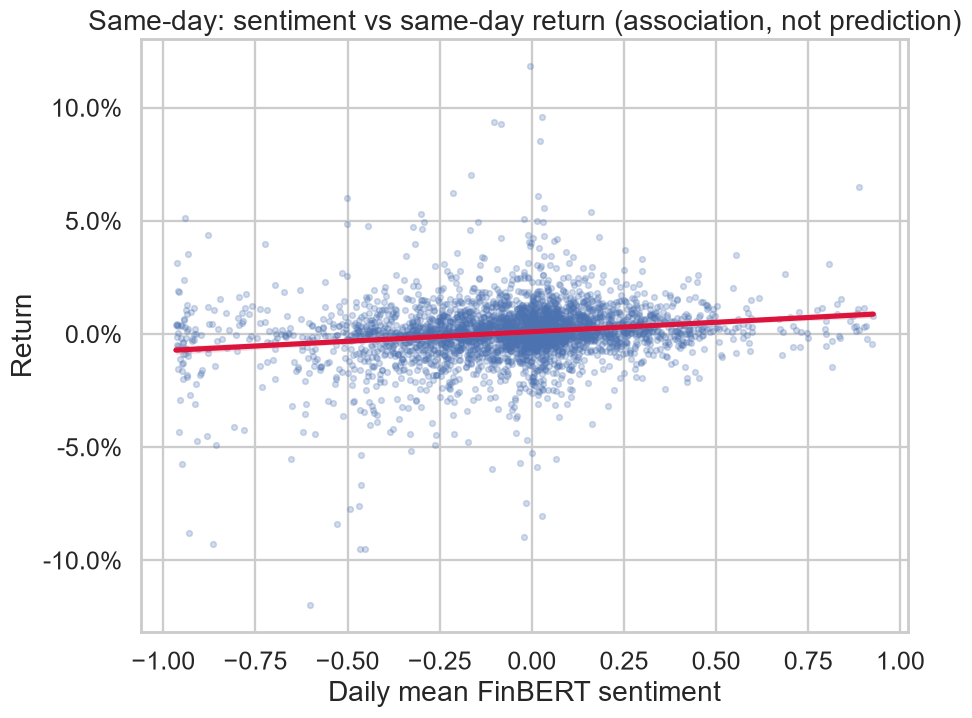

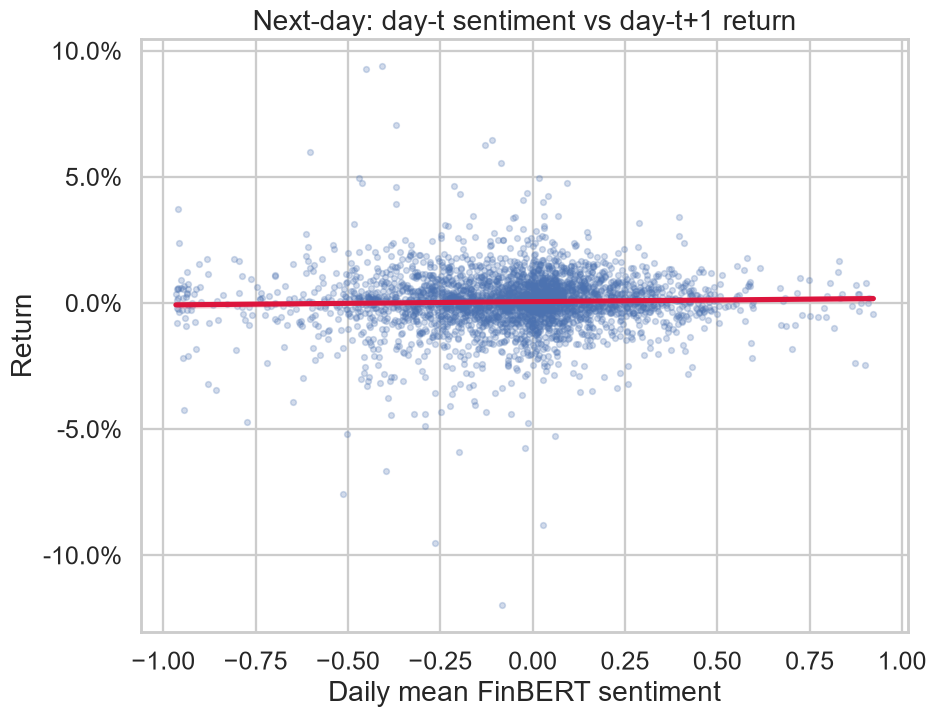

In [2]:
from src.plots import scatter_with_fit
from IPython.display import Image, display
scatter_with_fit(df, "ret", "Same-day: sentiment vs same-day return (association, not prediction)", "08_scatter_same_day.png")
scatter_with_fit(df, "next_ret", "Next-day: day-t sentiment vs day-t+1 return", "09_scatter_next_day.png")
display(Image("../reports/figures/08_scatter_same_day.png"))
display(Image("../reports/figures/09_scatter_next_day.png"))

## Regression with HAC (Newey–West) errors

Daily returns are autocorrelated and heteroskedastic, so plain OLS p-values
overstate confidence. Newey–West standard errors correct for that.

In [3]:
for ret_col, label in [("ret", "same-day"), ("next_ret", "next-day")]:
    res = hac_regression(df, ret_col)
    coef, p = res.params["sent_mean"], res.pvalues["sent_mean"]
    print(f"{label:>9}: coef = {coef:+.5f}   HAC p = {p:.4f}   (n = {int(res.nobs)})")

 same-day: coef = +0.00840   HAC p = 0.0000   (n = 3506)
 next-day: coef = +0.00132   HAC p = 0.0519   (n = 3210)


## Direction, not magnitude

Split days into sentiment terciles: how often is the *next* day up?

In [4]:
tbl = direction_table(df)
print(tbl.round(4))
print(f"\nchi-squared test of independence: chi2 = {tbl.attrs['chi2']:.2f}, p = {tbl.attrs['chi2_p']:.4f}")

            n  share_up  mean_next_ret
tercile                               
low      1070    0.5178        -0.0003
mid      1070    0.5299         0.0004
high     1070    0.5682         0.0010

chi-squared test of independence: chi2 = 5.97, p = 0.0504


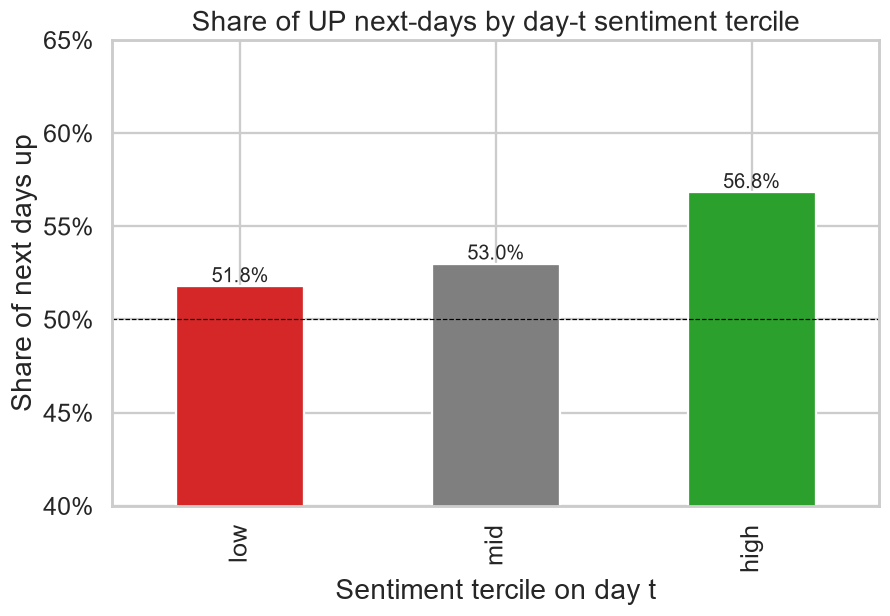

In [5]:
from src.plots import direction_by_tercile
direction_by_tercile(tbl)
Image("../reports/figures/05_direction_by_tercile.png")

## Where is the (weak) signal concentrated?

In [6]:
subgroup_correlations(df).round(4)

,subgroup,n,pearson_r,p
0,high news volume,1237,0.0173,0.5421
1,low news volume,1972,0.0410,0.0685
2,high volatility,1604,0.0416,0.0954
3,low volatility,1605,0.0162,0.5173


In [7]:
# Robustness: dense-coverage era only (2011+), where the dataset covers
# nearly every trading day.
dense = df[df.date >= "2011-01-01"]
print("2011+ only:")
print(corr_table(dense).round(4).to_string(index=False))

2011+ only:


relationship    n  pearson_r  pearson_p  spearman_r  spearman_p
    same-day 3179     0.1691     0.0000      0.1861      0.0000
    next-day 3067     0.0280     0.1205      0.0458      0.0112


## Reading

- **Same-day**: strong, highly significant positive association — but headlines
  written after the close guarantee some of this is the news *reporting* the move.
- **Next-day**: the association is an order of magnitude weaker. Whether it is
  statistically distinguishable from zero is the number that matters, and it is
  reported above exactly as computed.
- Any next-day tilt concentrates in high-volatility / high-news periods, which is
  consistent with the sentiment-spike literature rather than a steady daily edge.